# 03 - CNNs, Backbones e ViT

Executa experimentos comparaveis no PathMNIST 224x224: CNN propria, tres CNNs pre-treinadas de familias diferentes e um Vision Transformer.

In [12]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

def ensure_package(package, import_name=None):
    import_name = import_name or package.split('==')[0].replace('-', '_')
    if importlib.util.find_spec(import_name) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)

if IN_COLAB:
    ensure_package('medmnist==3.0.2', 'medmnist')
    ensure_package('pandas', 'pandas')
    ensure_package('matplotlib', 'matplotlib')

project_candidates = [Path.cwd(), Path.cwd().parent, Path('/content/AP2_IA'), Path('/content/ap2-ia'), Path('/content/drive/MyDrive/AP2_IA')]
PROJECT_ROOT = next((path for path in project_candidates if (path / 'src' / 'train.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao encontrei a raiz do projeto. Execute o notebook dentro da pasta do repositorio.')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from utils import collect_hardware_info, save_json, set_seed

SEED = 42
set_seed(SEED)
RESULTS_PATH = PROJECT_ROOT / 'experiments' / 'results.csv'
METADATA_DIR = PROJECT_ROOT / 'experiments' / 'metadata'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for path in [METADATA_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
save_json(PROJECT_ROOT / 'experiments' / 'hardware.json', collect_hardware_info())
print('Projeto:', PROJECT_ROOT)
print('GPU disponivel:', torch.cuda.is_available())

Projeto: /root/ap2-ia
GPU disponivel: True


In [13]:
FAST_FULL_STAGE3 = True
# Execucao rapida para cumprir toda a matriz da Etapa 3 no Colab.
# O relatorio deve justificar que o objetivo aqui e comparacao sob limite computacional, nao convergencia total.
EPOCHS = 1 if FAST_FULL_STAGE3 else 10
BATCH_SIZE = 16 if FAST_FULL_STAGE3 else 32
IMAGE_SIZE = 224
SOURCE_SIZE = 224
NUM_WORKERS = 0

def slug(parts):
    return '_'.join(str(part).replace('-', '').replace('.', 'p') for part in parts if part)

def completed_tags():
    if not RESULTS_PATH.exists():
        return set()
    df = pd.read_csv(RESULTS_PATH)
    if df.empty or 'tag' not in df.columns:
        return set()
    complete = df.groupby('tag')['epoca'].max()
    return set(complete[complete >= EPOCHS].index.astype(str))

def run_train(args, tag):
    metadata = METADATA_DIR / f'{tag}.json'
    command = [
        sys.executable, str(PROJECT_ROOT / 'src' / 'train.py'),
        *args,
        '--epochs', str(EPOCHS),
        '--batch-size', str(BATCH_SIZE),
        '--image-size', str(IMAGE_SIZE),
        '--source-size', str(SOURCE_SIZE),
        '--num-workers', str(NUM_WORKERS),
        '--seed', str(SEED),
        '--results', str(RESULTS_PATH),
        '--run-metadata', str(metadata),
        '--tag', tag,
    ]
    print(' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

experiments = []

# CNN propria.
experiments.append((['--model', 'custom_cnn', '--optimizer', 'adamw', '--lr', '1e-3'], 'custom_cnn_adamw_1e3'))

# Tres CNNs pre-treinadas: ResNet, EfficientNet e MobileNet.
# ResNet fine-tuning e coberto no grid obrigatorio abaixo para evitar experimento duplicado.
cnn_backbones = ['resnet50', 'efficientnet_b0', 'mobilenet_v3_large']
for backbone in cnn_backbones:
    experiments.append((['--model', backbone, '--mode', 'feature_extraction', '--optimizer', 'adamw', '--lr', '1e-3'], f'{backbone}_feature_extraction_adamw_1e3'))
    if backbone != 'resnet50':
        experiments.append((['--model', backbone, '--mode', 'fine_tuning', '--optimizer', 'adamw', '--lr', '1e-4'], f'{backbone}_fine_tuning_adamw_1e4'))

# Vision Transformer pre-treinado.
experiments.append((['--model', 'vit_b_16', '--mode', 'feature_extraction', '--optimizer', 'adamw', '--lr', '1e-3'], 'vit_b_16_feature_extraction_adamw_1e3'))
experiments.append((['--model', 'vit_b_16', '--mode', 'fine_tuning', '--optimizer', 'adamw', '--lr', '1e-4'], 'vit_b_16_fine_tuning_adamw_1e4'))

# Grid obrigatorio: 2 otimizadores x 3 learning rates no backbone escolhido para busca.
grid_backbone = 'resnet50'
for optimizer in ['sgd', 'adamw']:
    for lr in ['1e-2', '1e-3', '1e-4']:
        tag = slug([grid_backbone, 'fine_tuning', optimizer, lr])
        experiments.append((['--model', grid_backbone, '--mode', 'fine_tuning', '--optimizer', optimizer, '--lr', lr], tag))

manifest = [{'tag': tag, 'args': args} for args, tag in experiments]
save_json(PROJECT_ROOT / 'experiments' / 'stage03_experiment_manifest.json', {'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'image_size': IMAGE_SIZE, 'source_size': SOURCE_SIZE, 'experiments': manifest})
pd.DataFrame(manifest)

,tag,args
0,custom_cnn_adamw_1e3,"[--model, custom_cnn, --optimizer, adamw, --lr..."
1,resnet50_feature_extraction_adamw_1e3,"[--model, resnet50, --mode, feature_extraction..."
2,efficientnet_b0_feature_extraction_adamw_1e3,"[--model, efficientnet_b0, --mode, feature_ext..."
3,efficientnet_b0_fine_tuning_adamw_1e4,"[--model, efficientnet_b0, --mode, fine_tuning..."
4,mobilenet_v3_large_feature_extraction_adamw_1e3,"[--model, mobilenet_v3_large, --mode, feature_..."
5,mobilenet_v3_large_fine_tuning_adamw_1e4,"[--model, mobilenet_v3_large, --mode, fine_tun..."
6,vit_b_16_feature_extraction_adamw_1e3,"[--model, vit_b_16, --mode, feature_extraction..."
7,vit_b_16_fine_tuning_adamw_1e4,"[--model, vit_b_16, --mode, fine_tuning, --opt..."
8,resnet50_fine_tuning_sgd_1e2,"[--model, resnet50, --mode, fine_tuning, --opt..."
9,resnet50_fine_tuning_sgd_1e3,"[--model, resnet50, --mode, fine_tuning, --opt..."


In [14]:
RUN_EXPERIMENTS = True

if RUN_EXPERIMENTS:
    done = completed_tags()
    pending = [(args, tag) for args, tag in experiments if tag not in done]
    print(f'Ja concluidos: {len(done)} | pendentes nesta sessao: {len(pending)}')
    for args, tag in pending:
        run_train(args, tag)
    if not pending:
        print('Todos os experimentos do manifesto ja estao registrados em results.csv.')
else:
    print('RUN_EXPERIMENTS=False: manifest salvo, mas nenhum treino foi executado.')

Ja concluidos: 0 | pendentes nesta sessao: 14
/usr/bin/python3 /root/ap2-ia/src/train.py --model custom_cnn --optimizer adamw --lr 1e-3 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/custom_cnn_adamw_1e3.json --tag custom_cnn_adamw_1e3


100%|██████████| 12.6G/12.6G [36:34<00:00, 5.75MB/s]  


/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode feature_extraction --optimizer adamw --lr 1e-3 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_feature_extraction_adamw_1e3.json --tag resnet50_feature_extraction_adamw_1e3
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


/usr/bin/python3 /root/ap2-ia/src/train.py --model efficientnet_b0 --mode feature_extraction --optimizer adamw --lr 1e-3 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/efficientnet_b0_feature_extraction_adamw_1e3.json --tag efficientnet_b0_feature_extraction_adamw_1e3
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


...

/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode fine_tuning --optimizer sgd --lr 1e-3 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_fine_tuning_sgd_1e3.json --tag resnet50_fine_tuning_sgd_1e3


/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode fine_tuning --optimizer sgd --lr 1e-4 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_fine_tuning_sgd_1e4.json --tag resnet50_fine_tuning_sgd_1e4


/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode fine_tuning --optimizer adamw --lr 1e-2 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_fine_tuning_adamw_1e2.json --tag resnet50_fine_tuning_adamw_1e2


/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode fine_tuning --optimizer adamw --lr 1e-3 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_fine_tuning_adamw_1e3.json --tag resnet50_fine_tuning_adamw_1e3


/usr/bin/python3 /root/ap2-ia/src/train.py --model resnet50 --mode fine_tuning --optimizer adamw --lr 1e-4 --epochs 1 --batch-size 16 --image-size 224 --source-size 224 --num-workers 0 --seed 42 --results /root/ap2-ia/experiments/results.csv --run-metadata /root/ap2-ia/experiments/metadata/resnet50_fine_tuning_adamw_1e4.json --tag resnet50_fine_tuning_adamw_1e4


In [15]:
results = pd.read_csv(RESULTS_PATH)
if results.empty:
    raise RuntimeError('experiments/results.csv esta vazio. Execute a celula de treino antes de analisar.')
group_cols = ['tag'] if 'tag' in results.columns else ['modelo', 'modo', 'otimizador', 'lr']
best_by_run = results.sort_values('acc_val').groupby(group_cols, as_index=False).tail(1)
best_by_run = best_by_run.sort_values('acc_val', ascending=False)
best_by_run.to_csv(PROJECT_ROOT / 'experiments' / 'stage03_best_by_run.csv', index=False)
best_by_run.head(15)

,tag,modelo,modo,otimizador,lr,epoca,loss_train,loss_val,acc_train,acc_val,tempo_s,vram_mb
8,resnet50_fine_tuning_sgd_1e2,resnet50,fine_tuning,sgd,0.0100,1,0.118260,0.025378,0.961454,0.992903,1152.658439,1653.359375
3,efficientnet_b0_fine_tuning_adamw_1e4,efficientnet_b0,fine_tuning,adamw,0.0001,1,0.241766,0.034609,0.933030,0.991503,570.498954,1452.541504
5,mobilenet_v3_large_fine_tuning_adamw_1e4,mobilenet_v3_large,fine_tuning,adamw,0.0001,1,0.132571,0.027775,0.959176,0.991204,371.786585,770.144043
7,vit_b_16_fine_tuning_adamw_1e4,vit_b_16,fine_tuning,adamw,0.0001,1,0.077589,0.035632,0.977032,0.989104,3789.365741,3284.887695
13,resnet50_fine_tuning_adamw_1e4,resnet50,fine_tuning,adamw,0.0001,1,0.229611,0.041144,0.932541,0.988904,1171.380135,1747.516113
12,resnet50_fine_tuning_adamw_1e3,resnet50,fine_tuning,adamw,0.0010,1,0.097277,0.039776,0.969065,0.988205,1171.914631,1747.516113
9,resnet50_fine_tuning_sgd_1e3,resnet50,fine_tuning,sgd,0.0010,1,0.301618,0.086214,0.913274,0.974310,1152.992543,1653.359375
11,resnet50_fine_tuning_adamw_1e2,resnet50,fine_tuning,adamw,0.0100,1,0.261135,0.088701,0.919874,0.974210,1165.330515,1747.516113
6,vit_b_16_feature_extraction_adamw_1e3,vit_b_16,feature_extraction,adamw,0.0010,1,0.139539,0.091755,0.958709,0.972011,3427.125204,473.889648
1,resnet50_feature_extraction_adamw_1e3,resnet50,feature_extraction,adamw,0.0010,1,0.266741,0.119548,0.921074,0.967913,449.679866,277.886230


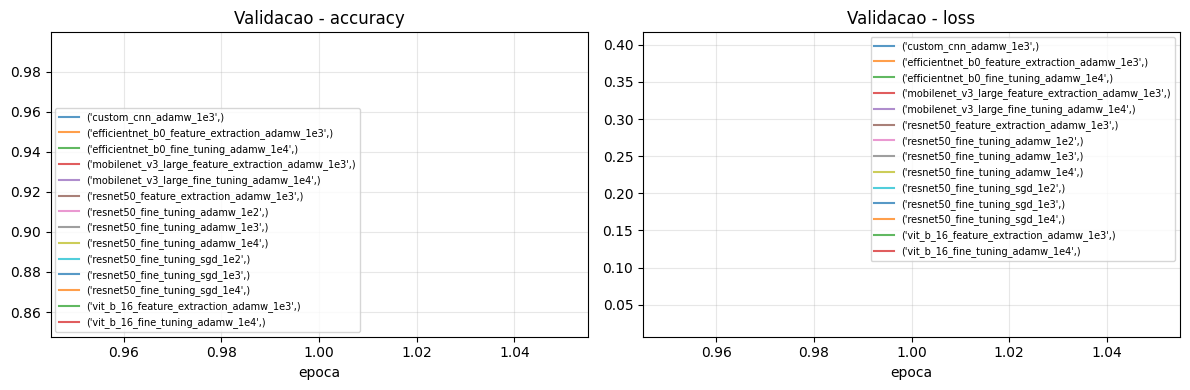

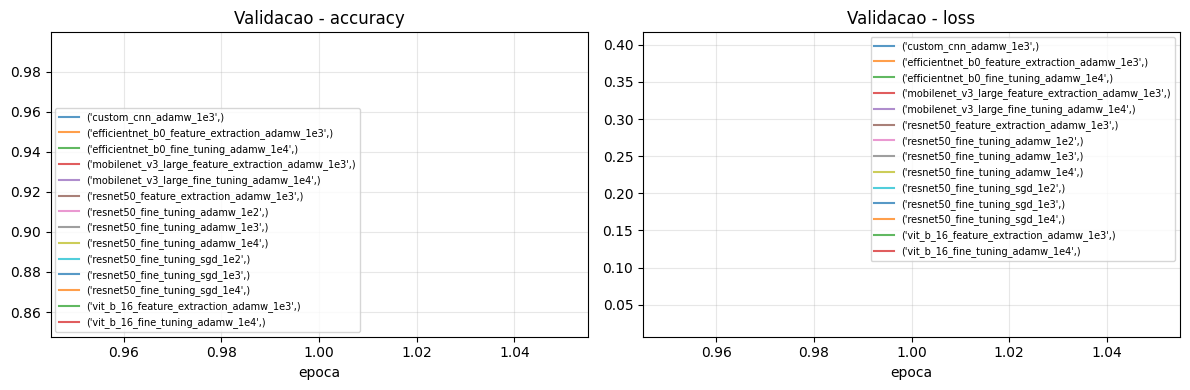

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key, group in results.groupby(group_cols):
    label = str(key)
    group.plot(x='epoca', y='acc_val', ax=axes[0], label=label, alpha=0.75)
    group.plot(x='epoca', y='loss_val', ax=axes[1], label=label, alpha=0.75)
axes[0].set_title('Validacao - accuracy')
axes[1].set_title('Validacao - loss')
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'stage03_validation_curves.png', dpi=160)
fig

Arquivos gerados: `experiments/results.csv`, `experiments/stage03_experiment_manifest.json`, `experiments/stage03_best_by_run.csv`, metadados em `experiments/metadata/` e curvas em `outputs/figures/stage03_validation_curves.png`. Checkpoint fica reservado para a Etapa 5.